# All Clone Types: Wasserstein Similarity Distributions

This notebook samples Type 1, Type 2, Type 3, and Type 4 BigCloneBench training pairs, scores each graph layer with the modified Wasserstein metric, plots clone vs non-clone score distributions, and computes decision thresholds per clone type.

Metric used here:

- `WassersteinSimilarity`: 1D Wasserstein distance mapped with `S = exp(-D / gamma)`.


In [11]:
from __future__ import annotations

import json
import pickle
import random
import sys
from dataclasses import dataclass
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from tqdm.auto import tqdm

PROJECT_ROOT = Path.cwd()
if PROJECT_ROOT.name != "Spectral-Software":
    matches = [p for p in [PROJECT_ROOT, *PROJECT_ROOT.parents] if p.name == "Spectral-Software"]
    if not matches:
        raise RuntimeError("Run this notebook from inside the Spectral-Software project.")
    PROJECT_ROOT = matches[0]

if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from spectral_code.similarity.distribution import WassersteinSimilarity

sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 120)

PROJECT_ROOT

WindowsPath('c:/Users/koush/PyProjects/Spectral-Software')

In [12]:
CLONE_TYPES = [1, 2, 3, 4]
GRAPH_TYPES = ["ast", "cfg", "ddg", "pdg", "cpg"]

BENCH_ROOT = PROJECT_ROOT / "bench_data"
OUTPUTS_ROOT = PROJECT_ROOT.parent / "outputs"
ANALYSIS_OUT = PROJECT_ROOT / "notebooks" / "analysis" / "outputs" / "wasserstein_all_types"
ANALYSIS_OUT.mkdir(parents=True, exist_ok=True)

# Sample size per clone type. Increase to 5_000+ for smoother plots, or set None for full train.txt.
MAX_PAIRS_PER_TYPE = 1_000
BALANCED_SAMPLE = True
RANDOM_SEED = 42

# Empty spectra are always dropped. Set this true to also drop spectra containing only zero values.
DROP_ALL_ZERO_SPECTRA = False

# Threshold objective: one of "f1", "accuracy", "precision", or "recall".
OPTIMIZE_FOR = "f1"

# Wasserstein gamma controls strictness. Smaller values push mismatches toward 0 faster.
WASSERSTEIN_GAMMA = 0.1
METRIC_NAME = f"wasserstein_gamma_{WASSERSTEIN_GAMMA:g}"
metric = WassersteinSimilarity(gamma=WASSERSTEIN_GAMMA)

print(f"Bench root:   {BENCH_ROOT}")
print(f"Outputs root: {OUTPUTS_ROOT}")
print(f"Analysis out: {ANALYSIS_OUT}")
print(f"Metric:       {METRIC_NAME}")


Bench root:   c:\Users\koush\PyProjects\Spectral-Software\bench_data
Outputs root: c:\Users\koush\PyProjects\outputs
Analysis out: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types
Metric:       wasserstein_gamma_0.1


In [13]:
@dataclass(frozen=True)
class PairRow:
    left_id: int
    right_id: int
    label: int


def load_train_pairs(data_dir: Path) -> list[PairRow]:
    path = data_dir / "train.txt"
    if not path.exists():
        raise FileNotFoundError(path)

    pairs: list[PairRow] = []
    with path.open("r", encoding="utf-8") as f:
        for line in f:
            left, right, label = line.rstrip("\n").split("\t")
            pairs.append(PairRow(int(left), int(right), int(label)))
    return pairs


def sample_pairs(pairs: list[PairRow], max_pairs: int | None, seed: int, balanced: bool = True) -> list[PairRow]:
    if max_pairs is None or max_pairs >= len(pairs):
        return pairs

    rng = random.Random(seed)
    if not balanced:
        return rng.sample(pairs, max_pairs)

    positives = [pair for pair in pairs if pair.label == 1]
    negatives = [pair for pair in pairs if pair.label == 0]
    half = max_pairs // 2
    pos_n = min(len(positives), half)
    neg_n = min(len(negatives), max_pairs - pos_n)

    sampled = rng.sample(positives, pos_n) + rng.sample(negatives, neg_n)
    if len(sampled) < max_pairs:
        used = set(sampled)
        remaining = [pair for pair in pairs if pair not in used]
        sampled.extend(rng.sample(remaining, min(max_pairs - len(sampled), len(remaining))))

    rng.shuffle(sampled)
    return sampled


def needed_method_ids(pairs: list[PairRow]) -> set[str]:
    ids: set[str] = set()
    for pair in pairs:
        ids.add(str(pair.left_id))
        ids.add(str(pair.right_id))
    return ids


def load_feature_records(manifest_path: Path, needed_ids: set[str]) -> dict[str, dict]:
    if not manifest_path.exists():
        raise FileNotFoundError(manifest_path)

    with manifest_path.open("r", encoding="utf-8") as f:
        manifest = json.load(f)

    if manifest.get("format") != "spectral_feature_shards_v1":
        raise ValueError(f"Unsupported spectral feature manifest: {manifest_path}")

    records: dict[str, dict] = {}
    for shard_path in tqdm(manifest["shards"], desc=f"Loading {manifest_path.parent.parent.name} shards", unit="shard"):
        with Path(shard_path).open("rb") as f:
            shard = pickle.load(f)

        for method_id, record in shard.items():
            method_key = str(method_id)
            if method_key in needed_ids:
                records[method_key] = record

        if len(records) >= len(needed_ids):
            break

    return records


def get_eigenvalues(features: dict[str, dict], method_id: int, graph_type: str) -> np.ndarray | None:
    record = features.get(str(method_id))
    if not record:
        return None

    values = record.get(graph_type, {}).get("eigenvalues", np.array([]))
    values = np.asarray(values, dtype=np.float64)
    if values.size == 0 or not np.all(np.isfinite(values)):
        return None
    if DROP_ALL_ZERO_SPECTRA and not np.any(np.abs(values) > 1e-10):
        return None
    return np.sort(values)


def score_type_graph_metric(
    clone_type: int,
    graph_type: str,
    metric_name: str,
    metric,
    pairs: list[PairRow],
    features: dict[str, dict],
) -> tuple[pd.DataFrame, dict]:
    rows = []
    dropped_missing = 0

    for pair in tqdm(pairs, desc=f"Type {clone_type} {graph_type.upper()} {metric_name}", leave=False):
        left_ev = get_eigenvalues(features, pair.left_id, graph_type)
        right_ev = get_eigenvalues(features, pair.right_id, graph_type)

        if left_ev is None or right_ev is None:
            dropped_missing += 1
            continue

        rows.append({
            "clone_type": f"type{clone_type}",
            "clone_type_num": clone_type,
            "graph_type": graph_type,
            "metric": metric_name,
            "left_id": pair.left_id,
            "right_id": pair.right_id,
            "label": pair.label,
            "class": "clone" if pair.label == 1 else "non_clone",
            "score": metric.compute(left_ev, right_ev),
            "left_spectrum_len": int(left_ev.size),
            "right_spectrum_len": int(right_ev.size),
        })

    diagnostics = {
        "clone_type": f"type{clone_type}",
        "graph_type": graph_type,
        "metric": metric_name,
        "input_pairs": len(pairs),
        "scored_pairs": len(rows),
        "dropped_missing_or_empty_spectra": dropped_missing,
    }
    return pd.DataFrame(rows), diagnostics

In [14]:
all_scores = []
all_diagnostics = []
sample_rows = []

for clone_type in CLONE_TYPES:
    data_dir = BENCH_ROOT / f"bcb_full_type{clone_type}"
    manifest_path = OUTPUTS_ROOT / f"type{clone_type}" / "spectral_features" / "spectral_features_manifest.json"

    pairs = load_train_pairs(data_dir)
    pairs = sample_pairs(pairs, MAX_PAIRS_PER_TYPE, RANDOM_SEED + clone_type, balanced=BALANCED_SAMPLE)
    ids = needed_method_ids(pairs)

    label_counts = pd.Series([pair.label for pair in pairs]).value_counts().to_dict()
    sample_rows.append({
        "clone_type": f"type{clone_type}",
        "sampled_pairs": len(pairs),
        "clone_pairs": int(label_counts.get(1, 0)),
        "nonclone_pairs": int(label_counts.get(0, 0)),
        "needed_methods": len(ids),
    })

    print(f"\nType {clone_type}: {len(pairs):,} sampled pairs, {len(ids):,} needed methods")
    features = load_feature_records(manifest_path, ids)
    print(f"Type {clone_type}: loaded {len(features):,} feature records")

    for graph_type in GRAPH_TYPES:
        score_df, diagnostics = score_type_graph_metric(
            clone_type, graph_type, METRIC_NAME, metric, pairs, features
        )
        all_scores.append(score_df)
        all_diagnostics.append(diagnostics)

scores_df = pd.concat(all_scores, ignore_index=True)
diagnostics_df = pd.DataFrame(all_diagnostics)
sample_df = pd.DataFrame(sample_rows)

scores_path = ANALYSIS_OUT / "all_types_wasserstein_scores.csv"
diagnostics_path = ANALYSIS_OUT / "all_types_wasserstein_diagnostics.csv"
sample_path = ANALYSIS_OUT / "all_types_wasserstein_sample_counts.csv"
scores_df.to_csv(scores_path, index=False)
diagnostics_df.to_csv(diagnostics_path, index=False)
sample_df.to_csv(sample_path, index=False)

print(f"Saved scores:      {scores_path}")
print(f"Saved diagnostics: {diagnostics_path}")
print(f"Saved sample info: {sample_path}")
display(sample_df)
display(diagnostics_df)


Type 1: 1,000 sampled pairs, 1,663 needed methods


Loading type1 shards:   0%|          | 0/108 [00:00<?, ?shard/s]

Type 1: loaded 1,663 feature records


Type 1 AST wasserstein_gamma_0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

Type 1 CFG wasserstein_gamma_0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

...

Type 4 PDG wasserstein_gamma_0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

Type 4 CPG wasserstein_gamma_0.1:   0%|          | 0/1000 [00:00<?, ?it/s]

Saved scores:      c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_scores.csv
Saved diagnostics: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_diagnostics.csv
Saved sample info: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_sample_counts.csv


,clone_type,sampled_pairs,clone_pairs,nonclone_pairs,needed_methods
0,type1,1000,500,500,1663
1,type2,1000,500,500,1332
2,type3,1000,500,500,1850
3,type4,1000,500,500,1942


,clone_type,graph_type,metric,input_pairs,scored_pairs,dropped_missing_or_empty_spectra
0,type1,ast,wasserstein_gamma_0.1,1000,915,85
1,type1,cfg,wasserstein_gamma_0.1,1000,915,85
2,type1,ddg,wasserstein_gamma_0.1,1000,915,85
3,type1,pdg,wasserstein_gamma_0.1,1000,915,85
4,type1,cpg,wasserstein_gamma_0.1,1000,915,85
5,type2,ast,wasserstein_gamma_0.1,1000,922,78
6,type2,cfg,wasserstein_gamma_0.1,1000,922,78
7,type2,ddg,wasserstein_gamma_0.1,1000,922,78
8,type2,pdg,wasserstein_gamma_0.1,1000,922,78
9,type2,cpg,wasserstein_gamma_0.1,1000,922,78


In [15]:
def q05(x): return x.quantile(0.05)
def q25(x): return x.quantile(0.25)
def q75(x): return x.quantile(0.75)
def q95(x): return x.quantile(0.95)

summary_df = (
    scores_df
    .groupby(["clone_type", "clone_type_num", "graph_type", "metric", "class"], as_index=False)
    .agg(
        n=("score", "size"),
        mean=("score", "mean"),
        median=("score", "median"),
        std=("score", "std"),
        q05=("score", q05),
        q25=("score", q25),
        q75=("score", q75),
        q95=("score", q95),
        mean_left_spectrum_len=("left_spectrum_len", "mean"),
        mean_right_spectrum_len=("right_spectrum_len", "mean"),
    )
    .sort_values(["clone_type_num", "metric", "graph_type", "class"])
)

summary_path = ANALYSIS_OUT / "all_types_wasserstein_summary.csv"
summary_df.to_csv(summary_path, index=False)
print(f"Saved summary: {summary_path}")
display(summary_df)

Saved summary: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_summary.csv


,clone_type,clone_type_num,graph_type,metric,class,n,mean,median,std,q05,q25,q75,q95,mean_left_spectrum_len,mean_right_spectrum_len
0,type1,1,ast,wasserstein_gamma_0.1,clone,439,1.000000,1.000000,7.509878e-16,1.000000,1.000000,1.000000,1.000000,76.209567,76.209567
1,type1,1,ast,wasserstein_gamma_0.1,non_clone,476,0.443357,0.413433,1.819668e-01,0.188011,0.309344,0.555249,0.752306,36.993697,28.792017
2,type1,1,cfg,wasserstein_gamma_0.1,clone,439,1.000000,1.000000,1.098821e-15,1.000000,1.000000,1.000000,1.000000,29.300683,29.300683
3,type1,1,cfg,wasserstein_gamma_0.1,non_clone,476,0.284071,0.193557,2.754971e-01,0.020497,0.091465,0.362874,1.000000,14.411765,11.205882
4,type1,1,cpg,wasserstein_gamma_0.1,clone,439,1.000000,1.000000,7.410670e-16,1.000000,1.000000,1.000000,1.000000,76.209567,76.209567
5,type1,1,cpg,wasserstein_gamma_0.1,non_clone,476,0.437438,0.427238,1.626079e-01,0.207546,0.316909,0.532861,0.698251,36.993697,28.792017
6,type1,1,ddg,wasserstein_gamma_0.1,clone,439,1.000000,1.000000,1.048591e-15,1.000000,1.000000,1.000000,1.000000,30.378132,30.378132
7,type1,1,ddg,wasserstein_gamma_0.1,non_clone,476,0.333193,0.278813,2.091595e-01,0.111402,0.201941,0.391672,1.000000,14.804622,11.813025
8,type1,1,pdg,wasserstein_gamma_0.1,clone,439,1.000000,1.000000,1.119751e-15,1.000000,1.000000,1.000000,1.000000,30.952164,30.952164
9,type1,1,pdg,wasserstein_gamma_0.1,non_clone,476,0.329208,0.279820,2.137196e-01,0.098810,0.187081,0.391115,1.000000,15.710084,12.563025


In [16]:
def candidate_thresholds(scores: np.ndarray) -> np.ndarray:
    unique_scores = np.unique(scores)
    candidates = {0.0, 1.0}
    candidates.update(float(score) for score in unique_scores)

    if len(unique_scores) > 1:
        mids = (unique_scores[:-1] + unique_scores[1:]) / 2.0
        candidates.update(float(th) for th in mids)

    return np.array(sorted(candidates), dtype=np.float64)


def metric_value(accuracy: float, precision: float, recall: float, f1: float, optimize_for: str) -> float:
    if optimize_for == "accuracy":
        return accuracy
    if optimize_for == "precision":
        return precision
    if optimize_for == "recall":
        return recall
    if optimize_for == "f1":
        return f1
    raise ValueError(f"Unsupported OPTIMIZE_FOR={optimize_for!r}")


def best_binary_threshold(group: pd.DataFrame) -> pd.Series:
    labels = group["label"].to_numpy(dtype=np.int64)
    scores = group["score"].to_numpy(dtype=np.float64)

    if len(np.unique(labels)) < 2:
        return pd.Series({
            "best_threshold": np.nan,
            "optimized_score": np.nan,
            "accuracy": np.nan,
            "precision": np.nan,
            "recall": np.nan,
            "f1": np.nan,
            "valid_pairs": len(group),
            "clone_pairs": int(np.sum(labels == 1)),
            "nonclone_pairs": int(np.sum(labels == 0)),
        })

    best_key = None
    best_result = None
    for th in candidate_thresholds(scores):
        preds = (scores >= th).astype(np.int64)
        tp = int(np.sum((preds == 1) & (labels == 1)))
        fp = int(np.sum((preds == 1) & (labels == 0)))
        tn = int(np.sum((preds == 0) & (labels == 0)))
        fn = int(np.sum((preds == 0) & (labels == 1)))

        accuracy = (tp + tn) / len(labels)
        precision = tp / (tp + fp) if (tp + fp) else 0.0
        recall = tp / (tp + fn) if (tp + fn) else 0.0
        f1 = (2 * precision * recall / (precision + recall)) if (precision + recall) else 0.0
        optimized_score = metric_value(accuracy, precision, recall, f1, OPTIMIZE_FOR)

        # Tie-breaker prefers stronger precision and a stricter threshold when the target metric is equal.
        key = (optimized_score, accuracy, precision, f1, th)
        if best_key is None or key > best_key:
            best_key = key
            best_result = (th, optimized_score, accuracy, precision, recall, f1, tp, fp, tn, fn)

    th, optimized_score, accuracy, precision, recall, f1, tp, fp, tn, fn = best_result
    return pd.Series({
        "best_threshold": float(th),
        "optimized_for": OPTIMIZE_FOR,
        "optimized_score": float(optimized_score),
        "accuracy": float(accuracy),
        "precision": float(precision),
        "recall": float(recall),
        "f1": float(f1),
        "valid_pairs": len(group),
        "clone_pairs": int(np.sum(labels == 1)),
        "nonclone_pairs": int(np.sum(labels == 0)),
        "tp": tp,
        "fp": fp,
        "tn": tn,
        "fn": fn,
    })


threshold_df = (
    scores_df
    .groupby(["clone_type", "clone_type_num", "graph_type", "metric"], group_keys=False)
    .apply(best_binary_threshold)
    .reset_index()
    .sort_values(["clone_type_num", "optimized_score", "accuracy", "precision"], ascending=[True, False, False, False])
)

threshold_path = ANALYSIS_OUT / f"all_types_wasserstein_thresholds_by_type_graph_{OPTIMIZE_FOR}.csv"
threshold_df.to_csv(threshold_path, index=False)
print(f"Saved threshold table: {threshold_path}")
display(threshold_df)

Saved threshold table: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_thresholds_by_type_graph_f1.csv


,clone_type,clone_type_num,graph_type,metric,best_threshold,optimized_for,optimized_score,accuracy,precision,recall,f1,valid_pairs,clone_pairs,nonclone_pairs,tp,fp,tn,fn
2,type1,1,cpg,wasserstein_gamma_0.1,1.000000,f1,0.989853,0.990164,0.979911,1.000000,0.989853,915,439,476,439,9,467,0
0,type1,1,ast,wasserstein_gamma_0.1,1.000000,f1,0.984305,0.984699,0.969095,1.000000,0.984305,915,439,476,439,14,462,0
3,type1,1,ddg,wasserstein_gamma_0.1,1.000000,f1,0.972315,0.972678,0.946121,1.000000,0.972315,915,439,476,439,25,451,0
4,type1,1,pdg,wasserstein_gamma_0.1,1.000000,f1,0.972315,0.972678,0.946121,1.000000,0.972315,915,439,476,439,25,451,0
1,type1,1,cfg,wasserstein_gamma_0.1,1.000000,f1,0.953312,0.953005,0.910788,1.000000,0.953312,915,439,476,439,43,433,0
7,type2,2,cpg,wasserstein_gamma_0.1,1.000000,f1,0.993348,0.993492,0.986784,1.000000,0.993348,922,448,474,448,6,468,0
5,type2,2,ast,wasserstein_gamma_0.1,1.000000,f1,0.985699,0.985900,0.971800,1.000000,0.985699,922,448,474,448,13,461,0
8,type2,2,ddg,wasserstein_gamma_0.1,1.000000,f1,0.971800,0.971800,0.945148,1.000000,0.971800,922,448,474,448,26,448,0
9,type2,2,pdg,wasserstein_gamma_0.1,1.000000,f1,0.971800,0.971800,0.945148,1.000000,0.971800,922,448,474,448,26,448,0
6,type2,2,cfg,wasserstein_gamma_0.1,1.000000,f1,0.949153,0.947939,0.903226,1.000000,0.949153,922,448,474,448,48,426,0


In [17]:
best_by_type_df = (
    threshold_df
    .sort_values(["clone_type_num", "optimized_score", "accuracy", "precision"], ascending=[True, False, False, False])
    .groupby(["clone_type", "clone_type_num"], as_index=False)
    .head(1)
    .reset_index(drop=True)
)

best_by_type_path = ANALYSIS_OUT / f"best_wasserstein_threshold_per_type_{OPTIMIZE_FOR}.csv"
best_by_type_df.to_csv(best_by_type_path, index=False)
print(f"Saved best per-type thresholds: {best_by_type_path}")
display(best_by_type_df)

Saved best per-type thresholds: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\best_wasserstein_threshold_per_type_f1.csv


,clone_type,clone_type_num,graph_type,metric,best_threshold,optimized_for,optimized_score,accuracy,precision,recall,f1,valid_pairs,clone_pairs,nonclone_pairs,tp,fp,tn,fn
0,type1,1,cpg,wasserstein_gamma_0.1,1.000000,f1,0.989853,0.990164,0.979911,1.000000,0.989853,915,439,476,439,9,467,0
1,type2,2,cpg,wasserstein_gamma_0.1,1.000000,f1,0.993348,0.993492,0.986784,1.000000,0.993348,922,448,474,448,6,468,0
2,type3,3,cpg,wasserstein_gamma_0.1,0.648721,f1,0.919592,0.922910,0.920635,0.918552,0.919592,921,442,479,406,35,444,36
3,type4,4,cfg,wasserstein_gamma_0.1,0.404904,f1,0.870334,0.862786,0.815838,0.932632,0.870334,962,475,487,443,100,387,32


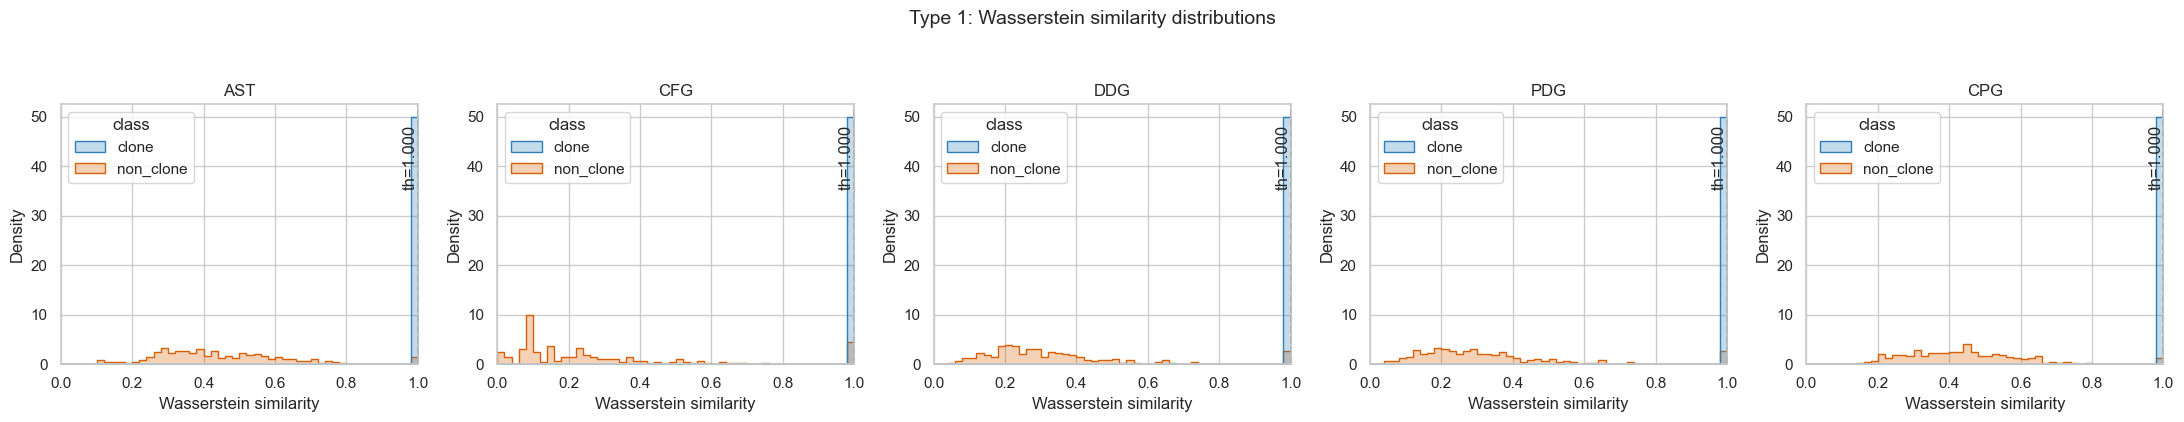

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\type1_wasserstein_gamma_0.1_distributions_with_thresholds.png


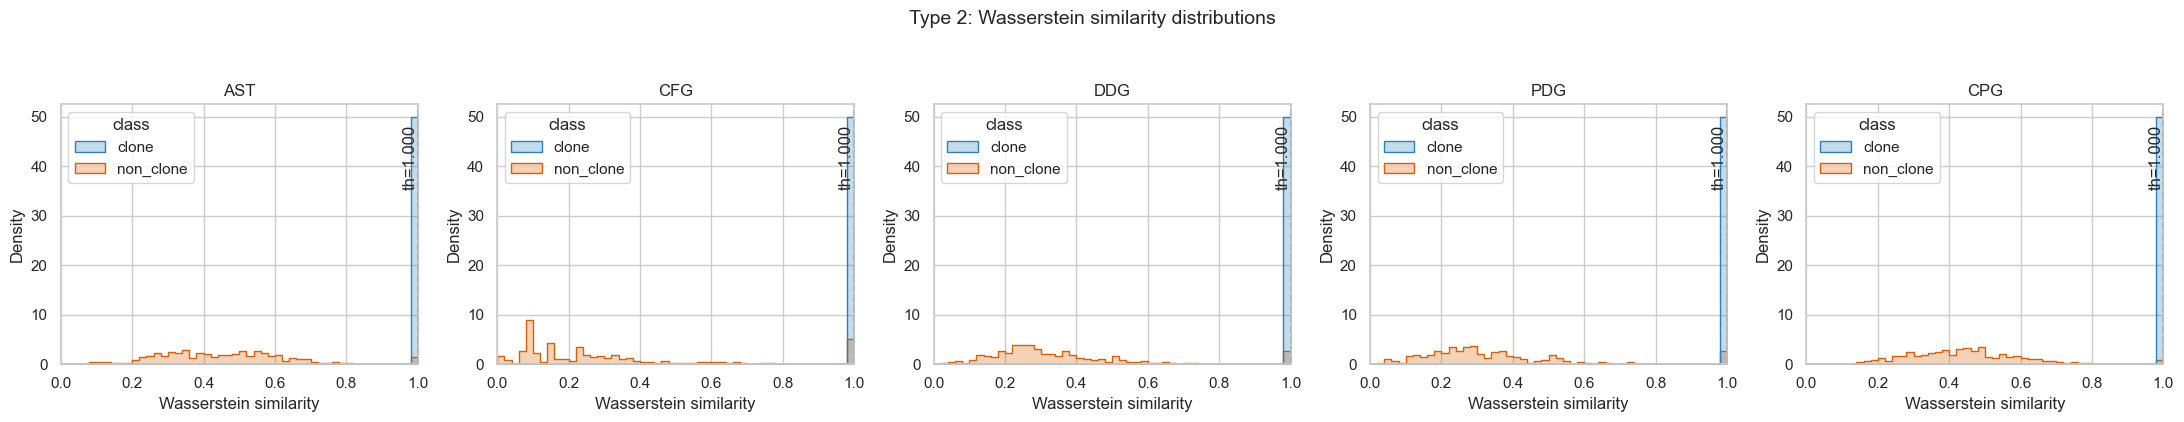

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\type2_wasserstein_gamma_0.1_distributions_with_thresholds.png


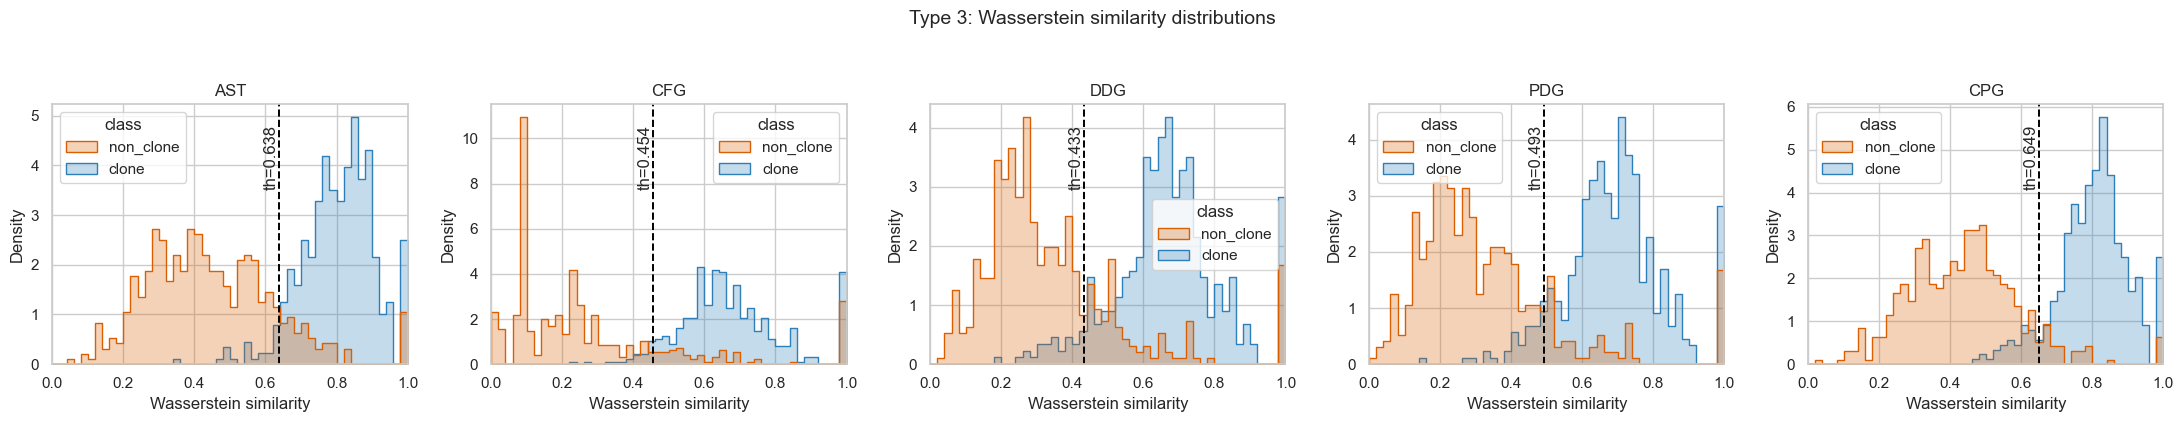

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\type3_wasserstein_gamma_0.1_distributions_with_thresholds.png


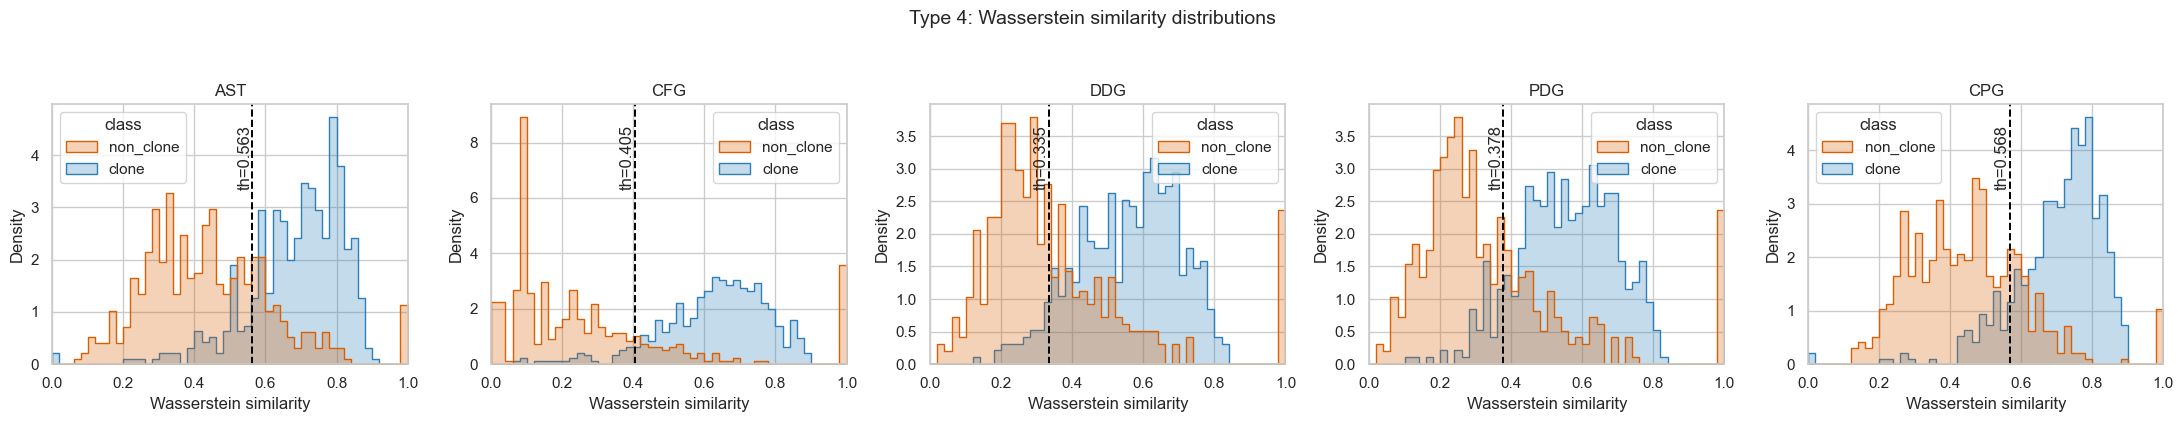

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\type4_wasserstein_gamma_0.1_distributions_with_thresholds.png


In [18]:
palette = {"clone": "#2c7fb8", "non_clone": "#d95f02"}

for clone_type in CLONE_TYPES:
    metric_name = METRIC_NAME
    type_metric_df = scores_df[
        (scores_df["clone_type_num"] == clone_type)
        & (scores_df["metric"] == metric_name)
    ]
    if type_metric_df.empty:
        continue

    fig, axes = plt.subplots(1, len(GRAPH_TYPES), figsize=(22, 4), sharex=True, sharey=False)
    for ax, graph_type in zip(axes, GRAPH_TYPES):
        plot_df = type_metric_df[type_metric_df["graph_type"] == graph_type]
        if plot_df.empty:
            ax.set_title(graph_type.upper())
            ax.set_axis_off()
            continue

        sns.histplot(
            data=plot_df,
            x="score",
            hue="class",
            bins=50,
            binrange=(0.0, 1.0),
            stat="density",
            common_norm=False,
            element="step",
            fill=True,
            alpha=0.28,
            palette=palette,
            ax=ax,
        )

        threshold_row = threshold_df[
            (threshold_df["clone_type_num"] == clone_type)
            & (threshold_df["metric"] == metric_name)
            & (threshold_df["graph_type"] == graph_type)
        ]
        if not threshold_row.empty and np.isfinite(threshold_row.iloc[0]["best_threshold"]):
            th = float(threshold_row.iloc[0]["best_threshold"])
            ax.axvline(th, color="black", linestyle="--", linewidth=1.4)
            ax.text(th, ax.get_ylim()[1] * 0.92, f"th={th:.3f}", rotation=90, va="top", ha="right")

        ax.set_title(graph_type.upper())
        ax.set_xlim(0.0, 1.0)
        ax.set_xlabel("Wasserstein similarity")
        ax.set_ylabel("Density")

    fig.suptitle(f"Type {clone_type}: Wasserstein similarity distributions", y=1.05, fontsize=14)
    fig.tight_layout()
    out_path = ANALYSIS_OUT / f"type{clone_type}_{metric_name}_distributions_with_thresholds.png"
    fig.savefig(out_path, dpi=160, bbox_inches="tight")
    plt.show()
    print(f"Saved: {out_path}")


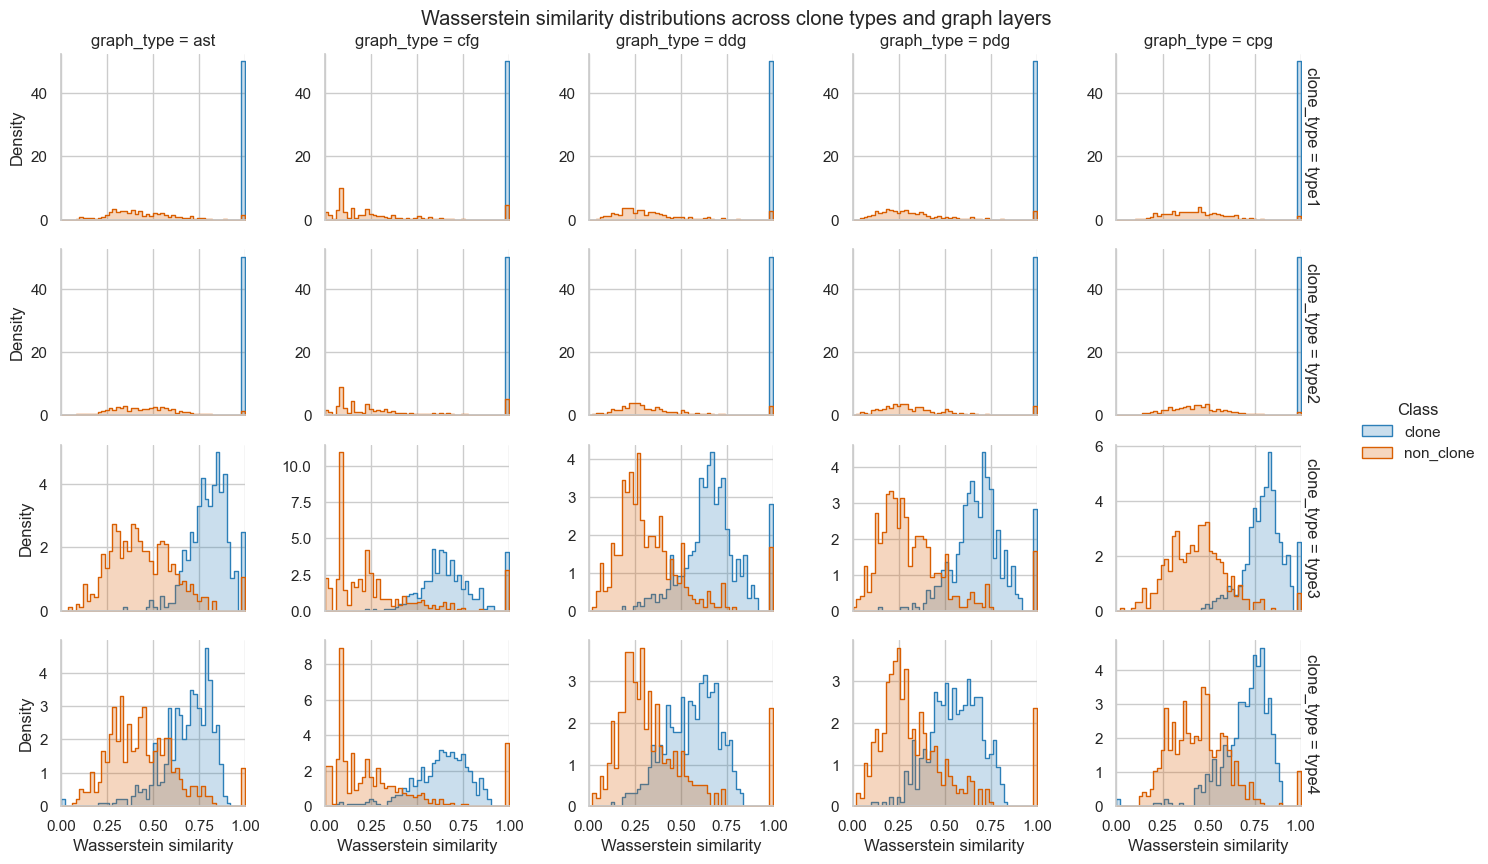

Saved: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_distribution_grid.png


In [19]:
metric_df = scores_df[scores_df["metric"] == METRIC_NAME]

grid = sns.FacetGrid(
    metric_df,
    row="clone_type",
    col="graph_type",
    hue="class",
    hue_order=["clone", "non_clone"],
    palette=palette,
    margin_titles=True,
    height=2.2,
    aspect=1.25,
    sharex=True,
    sharey=False,
)
grid.map_dataframe(
    sns.histplot,
    x="score",
    bins=50,
    binrange=(0.0, 1.0),
    stat="density",
    common_norm=False,
    element="step",
    fill=True,
    alpha=0.25,
)
grid.set_axis_labels("Wasserstein similarity", "Density")
grid.set(xlim=(0.0, 1.0))
grid.add_legend(title="Class")
grid.fig.subplots_adjust(top=0.93)
grid.fig.suptitle("Wasserstein similarity distributions across clone types and graph layers")

facet_path = ANALYSIS_OUT / "all_types_wasserstein_distribution_grid.png"
grid.fig.savefig(facet_path, dpi=160, bbox_inches="tight")
plt.show()
print(f"Saved: {facet_path}")


In [20]:
if "clone_type_num" not in summary_df.columns:
    summary_df = summary_df.copy()
    summary_df["clone_type_num"] = summary_df["clone_type"].str.extract(r"type(\d+)").astype(int)

mean_gap_df = summary_df.pivot_table(
    index=["clone_type", "clone_type_num", "graph_type", "metric"],
    columns="class",
    values="mean",
).reset_index()

mean_gap_df.columns.name = None
for required_col in ["clone", "non_clone"]:
    if required_col not in mean_gap_df.columns:
        mean_gap_df[required_col] = np.nan

mean_gap_df["clone_minus_nonclone_mean"] = mean_gap_df["clone"] - mean_gap_df["non_clone"]
mean_gap_df = mean_gap_df.sort_values("clone_minus_nonclone_mean", ascending=False)

gap_path = ANALYSIS_OUT / "all_types_wasserstein_mean_gaps.csv"
mean_gap_df.to_csv(gap_path, index=False)
print(f"Saved mean gaps: {gap_path}")
display(mean_gap_df)


Saved mean gaps: c:\Users\koush\PyProjects\Spectral-Software\notebooks\analysis\outputs\wasserstein_all_types\all_types_wasserstein_mean_gaps.csv


,clone_type,clone_type_num,graph_type,metric,clone,non_clone,clone_minus_nonclone_mean
1,type1,1,cfg,wasserstein_gamma_0.1,1.000000,0.284071,0.715929
6,type2,2,cfg,wasserstein_gamma_0.1,1.000000,0.308893,0.691107
4,type1,1,pdg,wasserstein_gamma_0.1,1.000000,0.329208,0.670792
3,type1,1,ddg,wasserstein_gamma_0.1,1.000000,0.333193,0.666807
9,type2,2,pdg,wasserstein_gamma_0.1,1.000000,0.340918,0.659082
8,type2,2,ddg,wasserstein_gamma_0.1,1.000000,0.345359,0.654641
2,type1,1,cpg,wasserstein_gamma_0.1,1.000000,0.437438,0.562562
0,type1,1,ast,wasserstein_gamma_0.1,1.000000,0.443357,0.556643
7,type2,2,cpg,wasserstein_gamma_0.1,1.000000,0.444811,0.555189
5,type2,2,ast,wasserstein_gamma_0.1,1.000000,0.453433,0.546567
